## Imports & config

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd()
if not (ROOT / "final_data").exists() and (ROOT.parent / "final_data").exists():
    ROOT = ROOT.parent

FINAL_DATA_DIR = ROOT / "final_data"
SPLIT_FOLDERS = {
    "train": "train",
    "val": "validate",
    "test": "test",
}
SPLIT_CSVS = {
    "train": ROOT / "train.csv",
    "val": ROOT / "val.csv",
    "test": ROOT / "test.csv",
}

LABELS = [
    "No gesture",
    "Swiping Down",
    "Swiping Left",
    "Swiping Right",
    "Swiping Up",
    "Turning Hand Clockwise",
    "Turning Hand Counterclockwise",
    "Zooming In With Two Fingers",
    "Zooming Out With Two Fingers",
]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

NUM_FRAMES = 37
INPUT_SIZE = 63
NUM_CLASSES = len(LABELS)
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 256
DROPOUT = 0.3
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Dataset

In [2]:
class GestureDataset(Dataset):
    def __init__(self, split):
        folder = SPLIT_FOLDERS[split]
        data_dir = FINAL_DATA_DIR / folder
        metadata = pd.read_csv(SPLIT_CSVS[split])

        self.samples = []
        for _, row in metadata.iterrows():
            video_id = int(row["video_id"])
            npy_path = data_dir / f"{video_id}.npy"
            if not npy_path.exists():
                continue
            self.samples.append(
                (npy_path, LABEL_TO_IDX[row["label"]])
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, label = self.samples[idx]
        seq = np.load(npy_path).astype(np.float32)
        return torch.from_numpy(seq), torch.tensor(label, dtype=torch.long)


train_dataset = GestureDataset("train")
val_dataset = GestureDataset("val")
test_dataset = GestureDataset("test")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 17605
Val:   2218
Test:  2197


## Transformer model

In [3]:
class GestureTransformer(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
        max_len=NUM_FRAMES,
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_proj(x) + self.pos_embedding[:, : x.size(1), :]
        x = self.transformer(x)
        x = x.mean(dim=1)
        logits = self.classifier(self.dropout(x))
        return logits


model = GestureTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

Trainable parameters: 279,049
GestureTransformer(
  (input_proj): Linear(in_features=63, out_features=128, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=9, bias=True)
)


## Training (early stopping on validation loss)

In [4]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for sequences, labels in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(sequences)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
model.to(device)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 01 | train loss 1.0472 acc 0.6177 | val loss 0.7291 acc 0.7719
Epoch 02 | train loss 0.5893 acc 0.8254 | val loss 0.5527 acc 0.8422
Epoch 03 | train loss 0.5026 acc 0.8537 | val loss 0.4983 acc 0.8616
Epoch 04 | train loss 0.4620 acc 0.8658 | val loss 0.4712 acc 0.8643
Epoch 05 | train loss 0.4501 acc 0.8694 | val loss 0.4646 acc 0.8661
Epoch 06 | train loss 0.4258 acc 0.8774 | val loss 0.4654 acc 0.8665
Epoch 07 | train loss 0.4086 acc 0.8795 | val loss 0.4216 acc 0.8787
Epoch 08 | train loss 0.3989 acc 0.8848 | val loss 0.4290 acc 0.8774
Epoch 09 | train loss 0.3870 acc 0.8860 | val loss 0.4359 acc 0.8787
Epoch 10 | train loss 0.4048 acc 0.8836 | val loss 0.4790 acc 0.8706
Epoch 11 | train loss 0.3872 acc 0.8854 | val loss 0.4461 acc 0.8792
Epoch 12 | train loss 0.3684 acc 0.8928 | val loss 0.4316 acc 0.8832
Epoch 13 | train loss 0.3734 acc 0.8890 | val loss 0.4216 acc 0.8787
Epoch 14 | train loss 0.3594 acc 0.8937 | val loss 0.4279 acc 0.8778
Early stopping at epoch 14
Best va

## Training curves

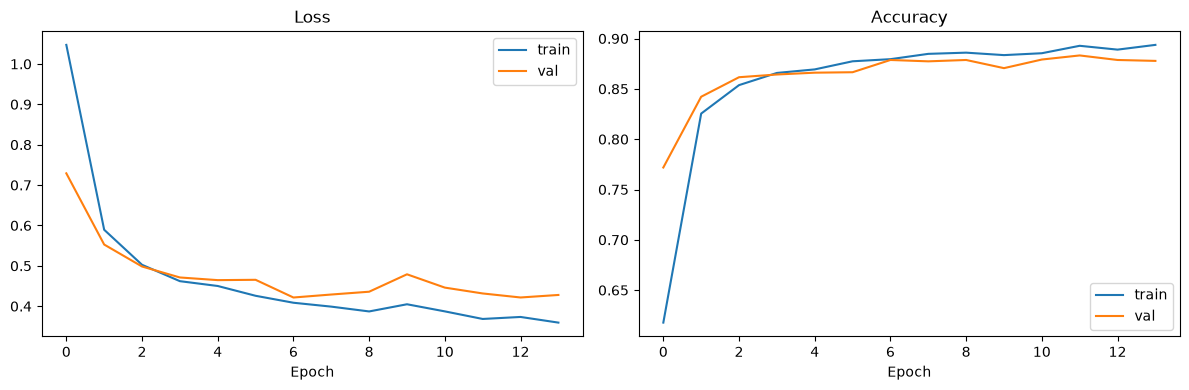

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Test evaluation

Test loss: 0.4218
Test accuracy: 0.8807

Classification report:
                               precision    recall  f1-score   support

                   No gesture     0.8737    0.9332    0.9025       719
                 Swiping Down     0.8363    0.9497    0.8894       199
                 Swiping Left     0.9226    0.8470    0.8832       183
                Swiping Right     0.8681    0.8927    0.8802       177
                   Swiping Up     0.9497    0.8854    0.9164       192
       Turning Hand Clockwise     0.8043    0.7255    0.7629       153
Turning Hand Counterclockwise     0.8392    0.7643    0.8000       157
  Zooming In With Two Fingers     0.9402    0.8398    0.8872       206
 Zooming Out With Two Fingers     0.8995    0.8910    0.8952       211

                     accuracy                         0.8807      2197
                    macro avg     0.8815    0.8587    0.8686      2197
                 weighted avg     0.8820    0.8807    0.8799      2197



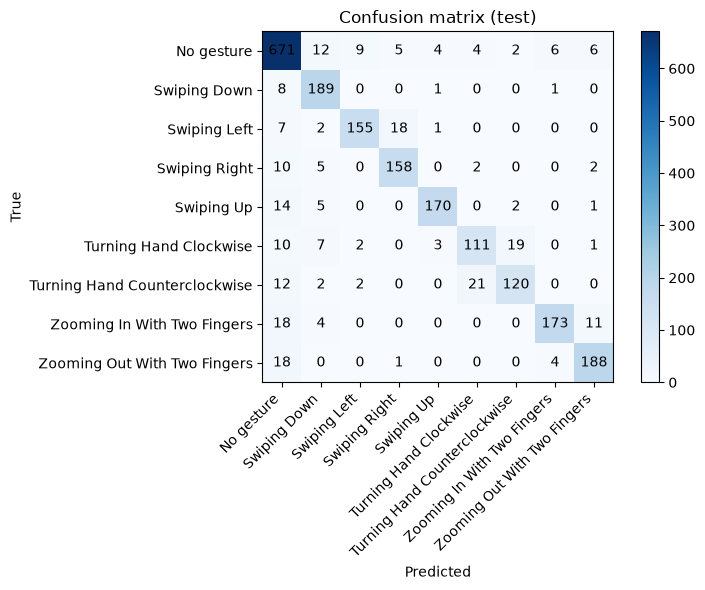

In [6]:
test_loss, test_acc = run_epoch(test_loader, model, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        logits = model(sequences)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()